# Training GCN model

## Import Lib and define paths

In [1]:
# === Path Variables ===# Healthy

import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import seaborn as sns  # For enhanced visualizations of heatmaps
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics

BASE_DIR = "../../../input_columns_1mm/input_columns"
QSM_DIR = "../../../QSM"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
THICKNESS_DIR = '../../../thickness_in_region'
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)
metadata_path = "../../../AD_DECODE_data3.xlsx"
df_metadata = pd.read_excel(metadata_path)


delete the abnormal QSM subjects

In [2]:
# The abnormal QSM subjects list
abnormal_qsm_subjects = [2765, 2320, 3343, 3350, 1412
                         , 1619, 3866, 2231]
# Delete the abnormal QSM subjects from the subject_df
subject_df = subject_df[~subject_df[0].isin(abnormal_qsm_subjects)]

In [3]:
# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#Load columns

# Base directory where subject folders (e.g., S00775_columns_1mm) are stored


In [4]:
# List of hemispheres
HEMIS = ["lh", "rh"]


In [5]:
# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]

region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

# Print region keys
print(region_keys)

['lh_bankssts', 'lh_caudalanteriorcingulate', 'lh_caudalmiddlefrontal', 'lh_cuneus', 'lh_entorhinal', 'lh_fusiform', 'lh_inferiorparietal', 'lh_inferiortemporal', 'lh_isthmuscingulate', 'lh_lateraloccipital', 'lh_lateralorbitofrontal', 'lh_lingual', 'lh_medialorbitofrontal', 'lh_middletemporal', 'lh_parahippocampal', 'lh_paracentral', 'lh_parsopercularis', 'lh_parsorbitalis', 'lh_parstriangularis', 'lh_pericalcarine', 'lh_postcentral', 'lh_posteriorcingulate', 'lh_precentral', 'lh_precuneus', 'lh_rostralanteriorcingulate', 'lh_rostralmiddlefrontal', 'lh_superiorfrontal', 'lh_superiorparietal', 'lh_superiortemporal', 'lh_supramarginal', 'lh_frontalpole', 'lh_temporalpole', 'lh_transversetemporal', 'lh_insula', 'rh_bankssts', 'rh_caudalanteriorcingulate', 'rh_caudalmiddlefrontal', 'rh_cuneus', 'rh_entorhinal', 'rh_fusiform', 'rh_inferiorparietal', 'rh_inferiortemporal', 'rh_isthmuscingulate', 'rh_lateraloccipital', 'rh_lateralorbitofrontal', 'rh_lingual', 'rh_medialorbitofrontal', 'rh_mi

## Read data

In [6]:
############################## METADATA ##############################

print("ADDECODE METADATA\n")

ADDECODE METADATA



In [7]:
# Zero-pad subject IDs to 5-digit strings
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()

In [8]:
# Standardize MRI_Exam IDs
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)


In [9]:
# Drop fully empty rows and rows missing MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])


In [10]:
# === Filter metadata to match only included subject IDs ===
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()


In [11]:
# === Only keep valid IDs for reordering to avoid KeyError ===
valid_ids = [sid for sid in subject_ids if sid in df_matched["MRI_Exam_fixed"].values]


In [12]:
# === Reorder safely ===
df_matched = df_matched.set_index("MRI_Exam_fixed").loc[valid_ids].reset_index()


In [13]:
# === Clean 'Risk' column: treat NaNs and empty strings as 'NoRisk' ===
df_matched["Risk"] = (
    df_matched["Risk"]
    .fillna("NoRisk")                              # Replace NaNs
    .replace(r'^\s*$', "NoRisk", regex=True)       # Replace empty strings or whitespace
    .str.strip()                                   # Remove leading/trailing spaces
)


In [14]:
# === Filter only MCI or AD risk subjects ===
df_matched_filtered = df_matched[df_matched["Risk"].isin(["MCI", "AD"])].copy()

In [15]:
# === Print summary ===
print("Remaining risk group distribution:")
print(df_matched_filtered["Risk"].value_counts())
print(f"\nSubjects before filtering: {len(df_matched)}")
print(f"Subjects after filtering:  {len(df_matched_filtered)}")


Remaining risk group distribution:
Risk
MCI    4
AD     1
Name: count, dtype: int64

Subjects before filtering: 64
Subjects after filtering:  5


In [16]:
# Build age_dict from the healthy metadata dataframe
age_dict = dict(zip(df_matched_filtered["MRI_Exam_fixed"], df_matched_filtered["age"]))


In [17]:
# === Extract filtered subject IDs (already cleaned and filtered to NoRisk / Familial) ===
subject_ids = df_matched_filtered["MRI_Exam_fixed"].tolist()


In [18]:
# === Initialize final dictionary: subject_id -> region -> matrix ===
column_data_md = {}
column_data_QSM = {}
column_data_thickness = {}


In [19]:
# === Loop through filtered subjects ===
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")  # Path to subject's folder
    subj_dict_thickness = {}
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder
    subj_dict_QSM = {}
    subj_dir_to_QSM = os.path.join(QSM_DIR, f"S{subj_id}", "QSM")  # Path to subject's QSM folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_md.csv"
            thickness_filename = f"S{subj_id}{region_key}_thickness.csv"
            QSM_filename = f"S{subj_id}_{region_key}_QSM.csv"
            # Construct full file path
            filepath = os.path.join(subj_dir, filename)
            thickness_filepath = os.path.join(subj_dir_to_thickness, thickness_filename)
            QSM_filepath = os.path.join(subj_dir_to_QSM, QSM_filename)

            if not os.path.exists(filepath):
                # print(f"[WARNING] Missing: {filepath}")
                continue
            if not os.path.exists(thickness_filepath):
                # print(f"[WARNING] Missing thickness file: {thickness_filepath}")
                continue

            if not os.path.exists(QSM_filepath):
                # print(f"[WARNING] Missing QSM file: {QSM_filepath}")
                continue

            # Load the thickness CSV matrix and get the mean thickness value
            thickness_mat = pd.read_csv(thickness_filepath, header=None).values.astype(np.float32)
            if thickness_mat.size == 0:
                print(f"[WARNING] Empty thickness matrix for {thickness_filepath}")
                continue
            # Calculate mean thickness for the region
            mean_thickness = np.mean(thickness_mat)
            subj_dict_thickness[region_key] = mean_thickness

            # Load MD CSV matrix as numpy array (float32)
            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            # Add mean thickness as an additional attribute to the matrix
            if mat.size == 0:
                print(f"[WARNING] Empty matrix for {filepath}")
                continue
            subj_dict[region_key] = mat

            # Load QSM CSV matrix as numpy array (float32)
            QSM_mat = pd.read_csv(QSM_filepath, header=None).values.astype(np.float32)
            if QSM_mat.size == 0:
                print(f"[WARNING] Empty QSM matrix for {QSM_filepath}")
                continue
            subj_dict_QSM[region_key] = QSM_mat



    if len(subj_dict) > 0:
        column_data_md[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_thickness) > 0:
        column_data_thickness[subj_id] = subj_dict_thickness
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_QSM) > 0:
        column_data_QSM[subj_id] = subj_dict_QSM
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")


In [20]:
# === OPTIONAL: Print region shapes for each subject ===
# for subj_id, regions in column_data.items():
#     print(f"\nSubject {subj_id}:")
#     for region_name, matrix in regions.items():
#         print(f"  {region_name} → {matrix.shape}")


## Construct Graphs

In [21]:
# CONSTRUCT GRAPHS 

import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors


In [22]:
# === STEP 1: Build edge_index from K-Nearest Neighbors ===

def build_knn_edge_index(x_np, k=10):
    """
    Builds the edge_index for a graph using KNN based on node features.

    Args:
        x_np (np.ndarray): shape [n_nodes, n_features]
        k (int): number of neighbors per node

    Returns:
        edge_index (torch.LongTensor): shape [2, num_edges]
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(x_np)
    knn_graph = knn.kneighbors_graph(x_np).tocoo()

    edge_index = torch.tensor(
        np.vstack((knn_graph.row, knn_graph.col)),
        dtype=torch.long
    )
    return edge_index


In [23]:
# === STEP 2: Build PyG graph from a single subject ===

def build_graph_from_subject(subj_id, column_data, age_dict, thickness_dict=None, k=10):
    """
    Builds a PyG Data object for a subject.
    If `thickness_dict` is provided, thickness will be attached as a global feature.
    """
    subj_regions = column_data[subj_id]
    # Optional: append thickness to the graph data
    x_np = np.vstack(list(subj_regions.values()))  # shape [N, F]
    if thickness_dict is not None and subj_id in thickness_dict:
        region_dict = thickness_dict[subj_id]  # dict: {region_key: value}
        
        # Use consistent ordering
        thickness_vec = [region_dict.get(key, 0.0) for key in region_keys]  # default to 0.0 for missing
        # Append thickness as an additional feature to each node
        thickness_column = np.array(thickness_vec).reshape(-1, 1)  #
        x_np = np.hstack((x_np, thickness_column))  # shape [N, F+1]
    x = torch.tensor(x_np, dtype=torch.float32)

    edge_index = build_knn_edge_index(x_np, k=k)
    y = torch.tensor([age_dict[subj_id]], dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.subject_id = subj_id

    return data


In [24]:
# === STEP 3: Loop through all subjects and build their graphs ===

# Standard scale the matrices
def standard_scale(matrix):
    """
    Standard scale a single matrix: (matrix - mean) / std
    """
    mean = matrix.mean()
    std = matrix.std()
    if std != 0:
        matrix = (matrix - mean) / std
    return matrix

# Standard scale the matrices in dictionaries
def standard_scale_dict(data_dict):
    """
    Apply standard scaling to all matrices in a nested dictionary structure
    """
    for subj_id, region_data in data_dict.items():
        for region_key, matrix in region_data.items():
            data_dict[subj_id][region_key] = standard_scale(matrix)
    return data_dict

# Standard scale thickness values across all subjects
def standard_scale_thickness_dict(thickness_dict, save_stats=True, stats_filename="thickness_scaling_stats.csv"):
    """
    Apply standard scaling to thickness values across all subjects and regions
    
    Args:
        thickness_dict: Dictionary of thickness values
        save_stats: Whether to save global mean and std to CSV
        stats_filename: Filename for saving statistics
    
    Returns:
        scaled thickness_dict and tuple of (global_mean, global_std)
    """
    # First, collect all thickness values across all subjects and regions
    all_thickness_values = []
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            all_thickness_values.append(thickness_value)
    
    # Calculate global mean and std
    all_thickness_array = np.array(all_thickness_values)
    global_mean = np.mean(all_thickness_array)
    global_std = np.std(all_thickness_array)
    
    print(f"Thickness scaling statistics:")
    print(f"  Global mean: {global_mean:.6f}")
    print(f"  Global std:  {global_std:.6f}")
    print(f"  Total values: {len(all_thickness_values)}")
    
    # Save statistics to CSV if requested
    if save_stats:
        stats_df = pd.DataFrame({
            'statistic': ['mean', 'std', 'count'],
            'value': [global_mean, global_std, len(all_thickness_values)]
        })
        stats_df.to_csv(stats_filename, index=False)
        print(f"  Saved scaling statistics to: {stats_filename}")
    
    # Apply scaling to each subject's thickness values
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            if global_std != 0:
                thickness_dict[subj_id][region_key] = (thickness_value - global_mean) / global_std
            else:
                thickness_dict[subj_id][region_key] = 0.0
    
    return thickness_dict, (global_mean, global_std)

print("Applying standard scaling to MD, QSM, and thickness data...")

# Apply standard scaling to all data
# column_data_md = standard_scale_dict(column_data_md)
column_data_QSM = standard_scale_dict(column_data_QSM)
# column_data_thickness, thickness_stats = standard_scale_thickness_dict(
#     column_data_thickness, 
#     save_stats=True, 
#     stats_filename="thickness_scaling_stats.csv"
# )

# print("Standard scaling completed!")

# Build MD graphs for each subject
graph_data_list_md = []
graph_data_list_QSM = []

for subj_id in subject_ids:
    if subj_id not in age_dict:
        continue

    # Build MD graph with thickness attached, and PCs
    if subj_id in column_data_md and subj_id in column_data_thickness:
        md_graph = build_graph_from_subject(subj_id, column_data_md, age_dict, thickness_dict=column_data_thickness)
        graph_data_list_md.append(md_graph)

    # Build QSM graph (no thickness)
    if subj_id in column_data_QSM:
        qsm_graph = build_graph_from_subject(subj_id, column_data_QSM, age_dict)
        graph_data_list_QSM.append(qsm_graph)

# Create lookup dictionary from subject IDs to their graphs
md_dict = {data.subject_id: data for data in graph_data_list_md}
qsm_dict = {data.subject_id: data for data in graph_data_list_QSM}

# Define region keys in a fixed order
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

# Build aligned list of MD, QSM graphs and thickness
aligned_graph_list = [
    (md_dict[sid], qsm_dict[sid])
    for sid in md_dict if sid in qsm_dict
]

Applying standard scaling to MD, QSM, and thickness data...


In [25]:
# === Example: How to load and use thickness scaling statistics in other scripts ===

def load_thickness_scaling_stats(stats_filename="thickness_scaling_stats.csv"):
    """
    Load thickness scaling statistics from CSV file
    
    Returns:
        tuple: (global_mean, global_std)
    """
    stats_df = pd.read_csv(stats_filename)
    stats_dict = dict(zip(stats_df['statistic'], stats_df['value']))
    
    global_mean = stats_dict['mean']
    global_std = stats_dict['std']
    
    print(f"Loaded thickness scaling statistics:")
    print(f"  Mean: {global_mean:.6f}")
    print(f"  Std:  {global_std:.6f}")
    
    return global_mean, global_std

def apply_thickness_scaling(thickness_value, global_mean, global_std):
    """
    Apply the same scaling used in training to new thickness values
    
    Args:
        thickness_value: Raw thickness value to scale
        global_mean: Global mean from training data
        global_std: Global std from training data
    
    Returns:
        Scaled thickness value
    """
    if global_std != 0:
        return (thickness_value - global_mean) / global_std
    else:
        return 0.0

# Example usage:
# mean, std = load_thickness_scaling_stats("thickness_scaling_stats.csv")
# scaled_thickness = apply_thickness_scaling(raw_thickness_value, mean, std)

In [26]:
def collate_fn_aligend(batch):
    md_data, qsm_data, _ = zip(*batch)  # we’ll re-fetch thickness below

    md_batch = Batch.from_data_list(md_data)
    qsm_batch = Batch.from_data_list(qsm_data)

    # Stack thickness from md_data (which now contains `.thickness`)
    thickness_tensor = torch.stack([d.thickness for d in md_data])

    return md_batch, qsm_batch, thickness_tensor

## Visualize graph_md ad graph_QSM


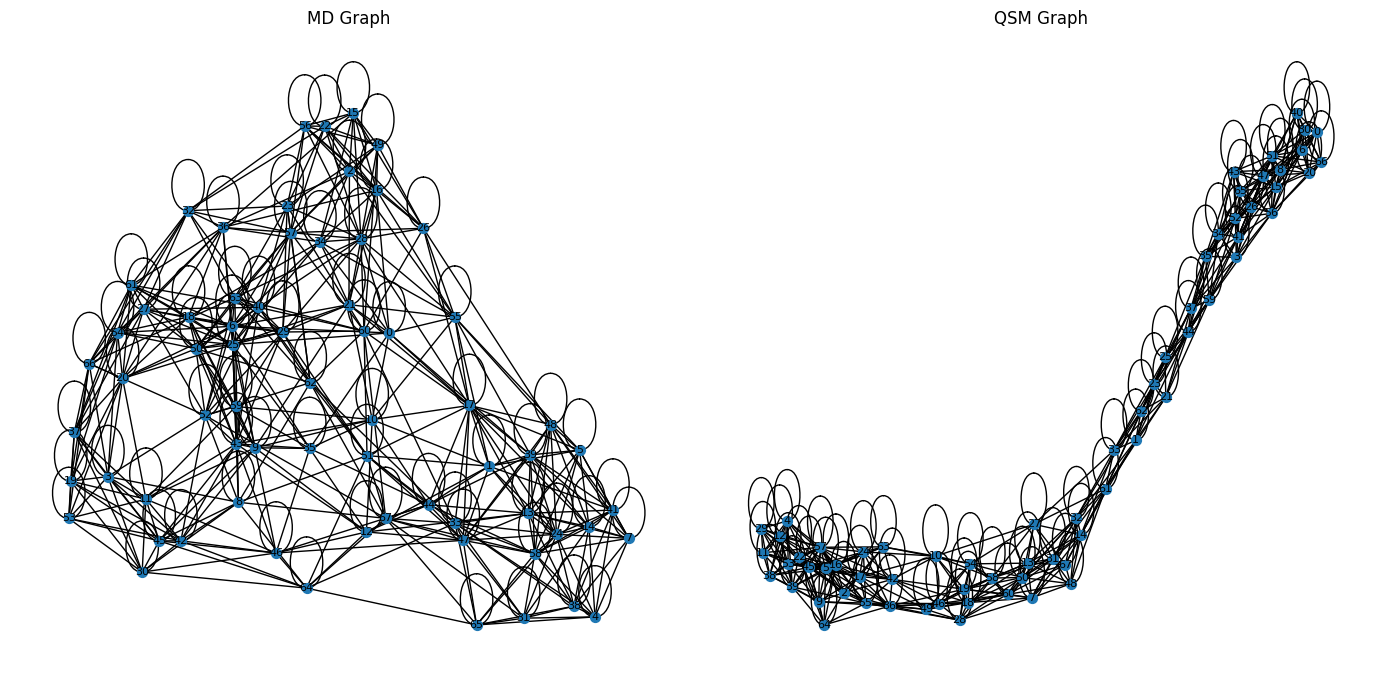

In [27]:

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


# === Pick the first subject's graph_md ===
graph_md = graph_data_list_md[0]

# === Convert PyG graph_md to NetworkX for visualization ===
G_md = to_networkx(graph_md, to_undirected=True)

# === Optional: layout (slower for large graphs) ===
pos_md = nx.spring_layout(G_md, seed=42)  # force-directed layout

graph_QSM = graph_data_list_QSM[0]
G_QSM = to_networkx(graph_QSM, to_undirected=True)
pos_QSM = nx.spring_layout(G_QSM, seed=42)  # force-directed layout

# === Plot the MD and QSM graphs side by side ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
# === MD Graph ===
nx.draw(G_md, pos=pos_md, with_labels=True, node_size=50, font_size=8, ax=ax1)
ax1.set_title("MD Graph")
# === QSM Graph ===
nx.draw(G_QSM, pos=pos_QSM, with_labels=True, node_size=50, font_size=8, ax=ax2)
ax2.set_title("QSM Graph")
plt.tight_layout()
plt.show()


In [28]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define Model GCN

In [29]:
#DEFINE MODEL GCNs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class BrainAgeGNN(nn.Module):
    def __init__(self, input_dim_md, input_dim_qsm):  # ← match your thickness vector size
        super(BrainAgeGNN, self).__init__()

        # GCN layers for MD
        self.md_conv1 = GCNConv(input_dim_md, 64)
        self.md_bn1 = BatchNorm(64)
        self.md_conv2 = GCNConv(64, 128)
        self.md_bn2 = BatchNorm(128)
        self.md_conv3 = GCNConv(128, 128)
        self.md_bn3 = BatchNorm(128)

        # GCN layers for QSM
        self.qsm_conv1 = GCNConv(input_dim_qsm, 64)
        self.qsm_bn1 = BatchNorm(64)
        self.qsm_conv2 = GCNConv(64, 128)
        self.qsm_bn2 = BatchNorm(128)
        self.qsm_conv3 = GCNConv(128, 128)
        self.qsm_bn3 = BatchNorm(128)

        self.dropout = nn.Dropout(p=0.5)

        # Final MLP
        self.fc = nn.Sequential(
            nn.Linear(128 + 128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, data_md, data_qsm, data_thickness=None):
        # MD stream
        x_md = F.relu(self.md_bn1(self.md_conv1(data_md.x, data_md.edge_index)))
        x_md = F.relu(self.md_bn2(self.md_conv2(x_md, data_md.edge_index)))
        x_md_res = x_md
        x_md = F.relu(self.md_bn3(self.md_conv3(x_md, data_md.edge_index)))
        x_md = x_md + x_md_res
        x_md = global_mean_pool(x_md, data_md.batch)
        x_md = self.dropout(x_md)

        # QSM stream
        x_qsm = F.relu(self.qsm_bn1(self.qsm_conv1(data_qsm.x, data_qsm.edge_index)))
        x_qsm = F.relu(self.qsm_bn2(self.qsm_conv2(x_qsm, data_qsm.edge_index)))
        x_qsm_res = x_qsm
        x_qsm = F.relu(self.qsm_bn3(self.qsm_conv3(x_qsm, data_qsm.edge_index)))
        x_qsm = x_qsm + x_qsm_res
        x_qsm = global_mean_pool(x_qsm, data_qsm.batch)
        x_qsm = self.dropout(x_qsm)

        # Combine MD, QSM, and thickness
        if data_thickness is not None:
            thickness = data_thickness  # already [B, R]
            x = torch.cat([x_md, x_qsm, thickness], dim=1)
        else:
            x = torch.cat([x_md, x_qsm], dim=1)

        return self.fc(x)


In [30]:
  #train and eval funcions  
    
from torch.optim import Adam
from torch_geometric.loader import DataLoader  # Usamos el DataLoader de torch_geometric

def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data_md, data_QSM in train_loader:
        data_md = data_md.to(device)  # GPU
        data_QSM = data_QSM.to(device)
        optimizer.zero_grad()
        output = model(data_md, data_QSM).view(-1)
        loss = criterion(output, data_md.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data_md, data_QSM in test_loader:
            data_md = data_md.to(device)
            data_QSM = data_QSM.to(device)
            output = model(data_md, data_QSM).view(-1)
            loss = criterion(output, data_md.y)
            total_loss += loss.item()
    return total_loss / len(test_loader)


## PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)

In [34]:
##################  PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)  ##################

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Ignore future warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

repeats_per_fold = 10
k =  7
batch_size = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# === Initialize storage ===

all_subject_ids = []
all_y_true = []
all_y_pred = []

# Create a new folder to save the y_true, y_pred, and subject_ids in each fold and repeat
if not os.path.exists("column_md_results"):
    os.makedirs("column_md_results")

for fold in range(k):
    print(f'\n--- Evaluating Fold {fold+1}/{k} ---')

    test_data = aligned_graph_list
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)
 
    repeat_maes = []
    repeat_r2s = []
    repeat_rmses = []

    for rep in range(repeats_per_fold):
        print(f"  > Repeat {rep+1}/{repeats_per_fold}")

        model = BrainAgeGNN(input_dim_md=22, input_dim_qsm=21).to(device)  # ← Your model

        model.load_state_dict(torch.load(f"column_md_model_fold_{fold+1}_rep_{rep+1}_ref.pt"))  # Load saved model
        model.eval()

        subject_id_repeat = []
        y_true_repeat = []
        y_pred_repeat = []

        subject_id_repeat_train = []
        y_true_repeat_train = []
        y_pred_repeat_train = []

        with torch.no_grad():
            for data_md, data_qsm in test_loader:
                data_md = data_md.to(device)
                data_qsm = data_qsm.to(device)
                output = model(data_md, data_qsm).view(-1)
                subject_id_repeat.extend(data_md.subject_id)
                y_pred_repeat.extend(output.cpu().tolist())
                y_true_repeat.extend(data_md.y.cpu().tolist())
            # Save predictions and true values to files
            test_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat,
                'y_true': y_true_repeat,
                'y_pred': y_pred_repeat
            })
            test_results_df.to_csv(f"column_MCIandAD/fold_{fold+1}_rep_{rep+1}_test_results_ref.csv", index=False)

        # Compute metrics
        mae = mean_absolute_error(y_true_repeat, y_pred_repeat)
        r2 = r2_score(y_true_repeat, y_pred_repeat)
        rmse = np.sqrt(mean_squared_error(y_true_repeat, y_pred_repeat))

        repeat_maes.append(mae)
        repeat_r2s.append(r2)
        repeat_rmses.append(rmse)

        all_y_true.extend(y_true_repeat)
        all_y_pred.extend(y_pred_repeat)
        all_subject_ids.extend(subject_id_repeat)



Using device: cuda

--- Evaluating Fold 1/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10

--- Evaluating Fold 2/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10

--- Evaluating Fold 3/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10

--- Evaluating Fold 4/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10

--- Evaluating Fold 5/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10

--- Evaluating Fold 6/7 ---
  

In [35]:
# Save all_y_true and all_y_pred to CSV
import pandas as pd
# Create a DataFrame from the true and predicted values
# For each subject, there're 7 folds and 10 repeats, so we can flatten the lists and match them
# all_y_true = 67 subjects * 10 repeats * 7 folds = 4690 values
# all_y_pred = 67 subjects * 10 repeats * 7 folds = 4690 values
# Flatten subject IDs if they are lists of lists
def flatten(l):
    return [item for sublist in l for item in sublist] if isinstance(l[0], list) else l

flat_subject_ids = flatten(all_subject_ids)

# Print the length of flat_subject_ids
print(f"Total subjects in flattened list: {len(flat_subject_ids)}")

Total subjects in flattened list: 350


In [36]:
df_results = pd.DataFrame({
    'subject_id': flat_subject_ids,
    'y_true': all_y_true,
    'y_pred': all_y_pred
})
# Save the mean and std of the predicted ages for each subject
df_results_mean_std = df_results.groupby('subject_id').agg(
    y_true_mean=('y_true', 'mean'),
    y_true_std=('y_true', 'std'),
    y_pred_mean=('y_pred', 'mean'),
    y_pred_std=('y_pred', 'std')
).reset_index()
# Save to CSV
df_results_mean_std.to_csv("column_based_gcn_results_ref_MCIandAD.csv", index=False)